# **House Price Prediction**
**🧾 Overview**
 - This dataset is a realistic synthetic house price dataset designed to simulate real-world real estate scenarios. It contains 50,000 records with 18 features, capturing various aspects of residential properties such as size, location, amenities, and socio-economic factors.

## **Step 1 : Importing libraries and data sets**

In [2]:
import pandas as pd   # to load the dataframe
import matplotlib.pyplot as plt # to visualize the features
import seaborn as sns # to see the correlation between features

In [3]:
df = pd.read_csv("/content/house_price_50k.csv")

In [4]:
df.head()

,area,bedrooms,bathrooms,floors,age,distance,garage,parking,garden,security,school_nearby,hospital_nearby,shopping_mall_nearby,public_transport,crime_rate,population_density,location,income_level,price
0,1360,6,2,2,9,10,0,0,1,0,1,0,1,0,6.939333,7242,premium,low,5.952493e+05
1,4272,5,2,3,24,8,1,0,0,1,1,1,1,0,0.400918,7729,low,low,1.571208e+06
2,3592,1,4,3,4,20,0,1,1,1,0,1,0,1,6.292386,1081,premium,mid,1.379943e+06
3,966,5,2,2,6,14,1,0,0,0,0,1,1,0,8.964112,8912,medium,low,4.367819e+05
4,4926,4,3,1,18,9,0,0,0,0,1,0,1,1,2.843309,8146,low,mid,1.792425e+06


In [5]:
df.shape

(50000, 19)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   area                  50000 non-null  int64  
 1   bedrooms              50000 non-null  int64  
 2   bathrooms             50000 non-null  int64  
 3   floors                50000 non-null  int64  
 4   age                   50000 non-null  int64  
 5   distance              50000 non-null  int64  
 6   garage                50000 non-null  int64  
 7   parking               50000 non-null  int64  
 8   garden                50000 non-null  int64  
 9   security              50000 non-null  int64  
 10  school_nearby         50000 non-null  int64  
 11  hospital_nearby       50000 non-null  int64  
 12  shopping_mall_nearby  50000 non-null  int64  
 13  public_transport      50000 non-null  int64  
 14  crime_rate            50000 non-null  float64
 15  population_density 

 ## **Step - 2 Data Preprocessing**

- **Categorize the features based on thier data types and count the number of features in each category.**

In [7]:
object_features = df.select_dtypes(include = "object").columns
print("Categorical variable:", len(object_features))

Categorical variable: 2


In [8]:
num_features = df.select_dtypes(include = ["int64", "float64"]).columns
print("Numerical features:", len(num_features))

Numerical features: 17


In [9]:
df.duplicated().sum()

np.int64(0)

## **Step -3: Exploratory Data Analysis**
 -  **EDA involves examining datasets uncover patterns, detect anomalies and understand the structure.**

In [10]:
df.describe()

,area,bedrooms,bathrooms,floors,age,distance,garage,parking,garden,security,school_nearby,hospital_nearby,shopping_mall_nearby,public_transport,crime_rate,population_density,price
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,5.000000e+04
mean,2752.970540,3.496040,2.498040,1.997060,19.573740,14.968700,0.500540,0.497300,0.500280,0.496220,0.501100,0.498320,0.498320,0.500040,5.006444,5065.94598,1.030261e+06
std,1297.148134,1.712146,1.117704,0.815368,11.552502,8.363714,0.500005,0.499998,0.500005,0.499991,0.500004,0.500002,0.500002,0.500005,2.876776,2864.34322,4.580199e+05
min,500.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000311,100.00000,9.090069e+04
25%,1630.000000,2.000000,1.000000,1.000000,10.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.523018,2575.00000,6.357375e+05
50%,2756.000000,3.000000,2.000000,2.000000,20.000000,15.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,5.022946,5060.50000,1.031763e+06
75%,3872.000000,5.000000,3.000000,3.000000,30.000000,22.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.479632,7543.00000,1.423102e+06
max,4999.000000,6.000000,4.000000,3.000000,39.000000,29.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,9.999869,9999.00000,1.996474e+06


In [11]:
# Check null values
df.isnull().sum()

,0
area,0
bedrooms,0
bathrooms,0
floors,0
age,0
distance,0
garage,0
parking,0
garden,0
security,0


In [12]:
# Convert data type in price
df['price'] =df['price'].astype(int)

In [13]:
# Check price column details
print("Data Tyep:", df['price'].dtype)
print("Min Price:", df['price'].min())
print("Max Price:", df['price'].max())
print("Mean Price:",df['price'].mean())
print("Null values:", df['price'].isnull().sum())
print("\sample values:\n", df['price'].head(10))

Data Tyep: int64
Min Price: 90900
Max Price: 1996474
Mean Price: 1030260.44348
Null values: 0
\sample values:
 0     595249
1    1571208
2    1379942
3     436781
4    1792424
5    1493336
6    1327557
7    1276640
8     247724
9     755324
Name: price, dtype: int64


<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_8563/2973664598.py:7: SyntaxWarning: invalid escape sequence '\s'
  print("\sample values:\n", df['price'].head(10))


In [15]:
# Check skewness
print("Skewness:", df['price'].skew())

Skewness: -0.007444317112388141


In [16]:
# Check for negative values
print("Negative price:", (df['price'] < 0).sum())

Negative price: 0


In [17]:
# Check for zero values
print("Zero prices", (df['price'] == 0).sum())

Zero prices 0


In [18]:
# Check for outliers
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

Outliers = df[(df['price'] < Q1 -1.5 * IQR) | (df['price'] > Q3 + 1.5 * IQR)]
print("Outliers count:", Outliers.shape[0])

Outliers count: 0


 - **For distribution numerical**

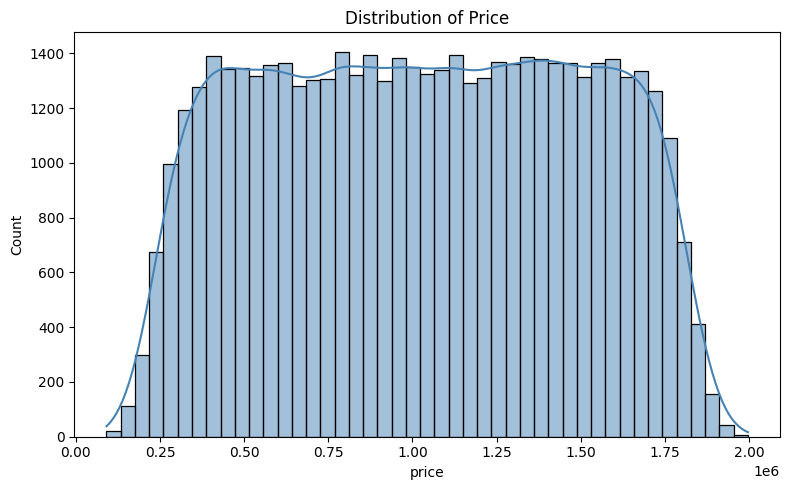

In [20]:
# Distribution target variable
plt.figure(figsize = (8, 5))
sns.histplot(df['price'], kde = True, color = 'steelblue')
plt.title("Distribution of Price")
plt.savefig('price_distribution.png')
plt.tight_layout()
plt.show()

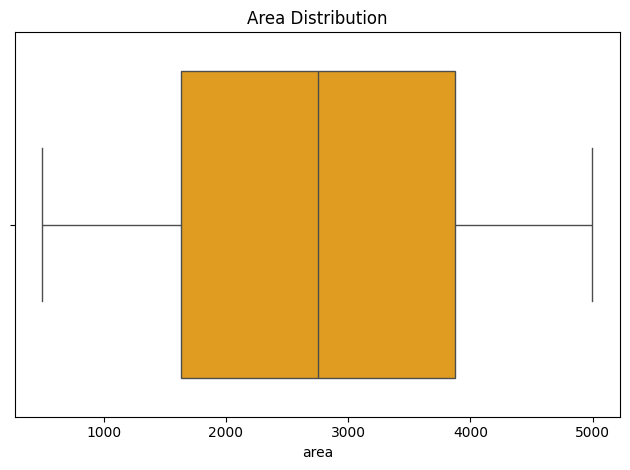

In [21]:
# Area distribution
sns.boxplot(x = df['area'], color = 'orange')
plt.title("Area Distribution")
plt.tight_layout()
plt.show()

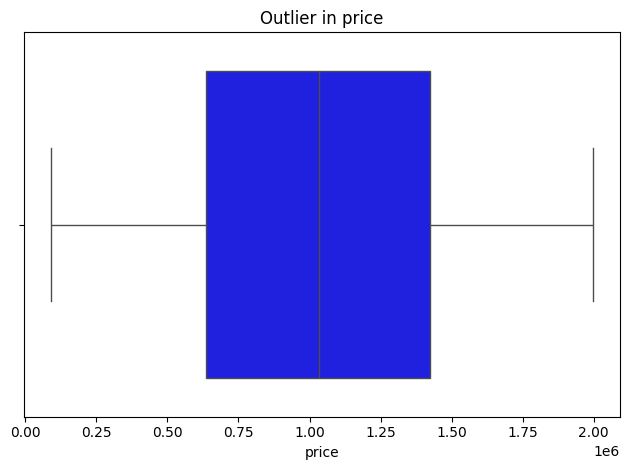

In [22]:
# USing boxplot cheking outliers
sns.boxplot(x = df['price'], color = 'Blue')
plt.title("Outlier in price")
plt.tight_layout()
plt.show()

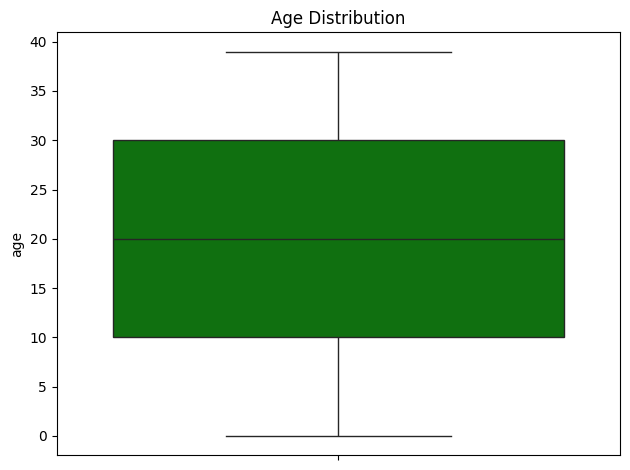

In [23]:
# Age distribution
sns.boxplot(df['age'], color = 'green')
plt.title('Age Distribution')
plt.tight_layout()
plt.show()

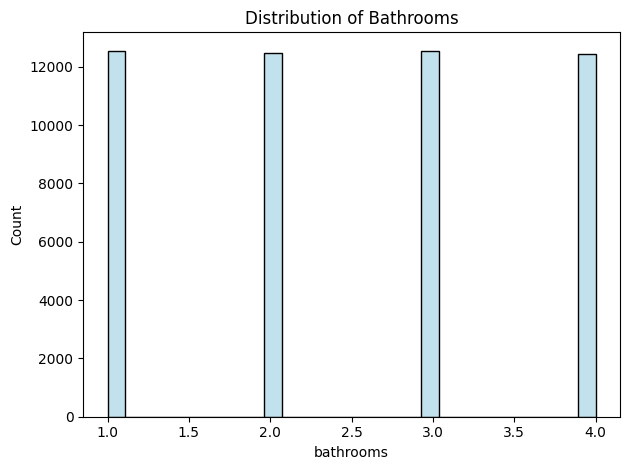

In [24]:
# Distribution number of bathrooms
sns.histplot(df['bathrooms'], kde = False , color = 'lightblue')
plt.title("Distribution of Bathrooms")
plt.tight_layout()
plt.show()

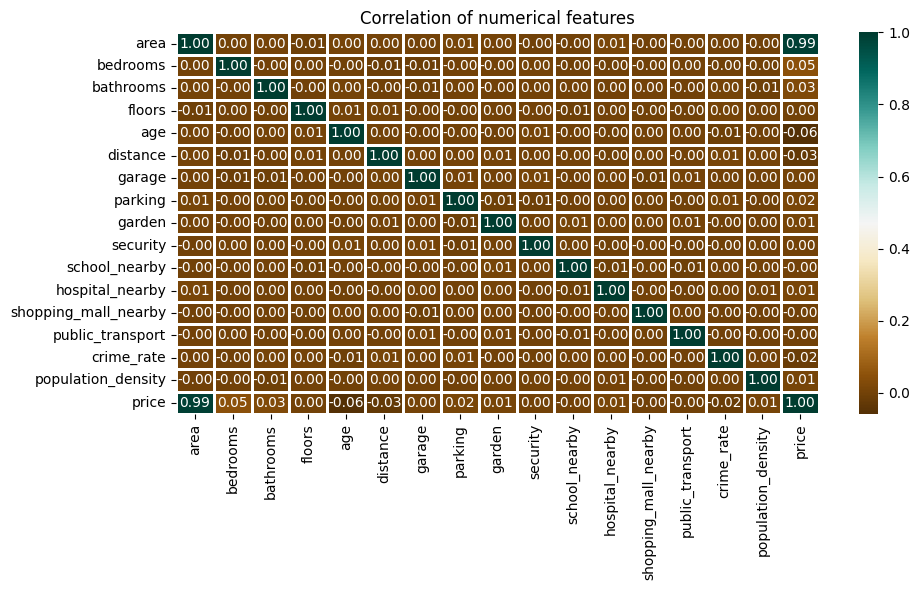

In [25]:
# Using heatmap to visualize the correlation between features
plt.figure(figsize = (10, 6))
sns.heatmap(df.corr(numeric_only = True), cmap= 'BrBG',
                fmt = '.2f', annot = True, linewidths = 1)
plt.title("Correlation of numerical features")
plt.tight_layout()
plt.show()

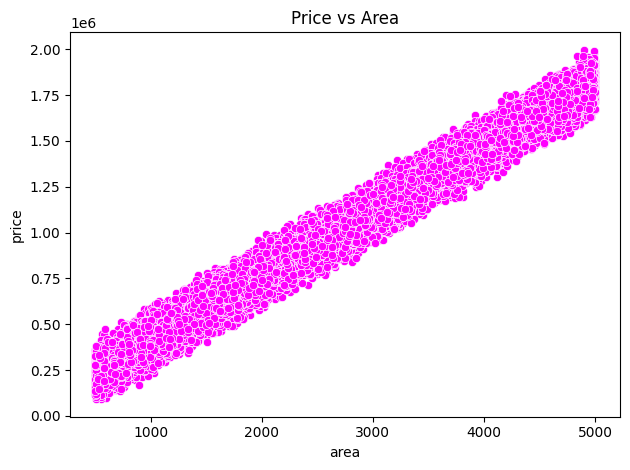

In [59]:
sns.scatterplot(x = 'area', y = 'price', data = df, color = 'magenta')
plt.title("Price vs Area")
plt.tight_layout()
plt.savefig('price_vs_area.png')
plt.show()

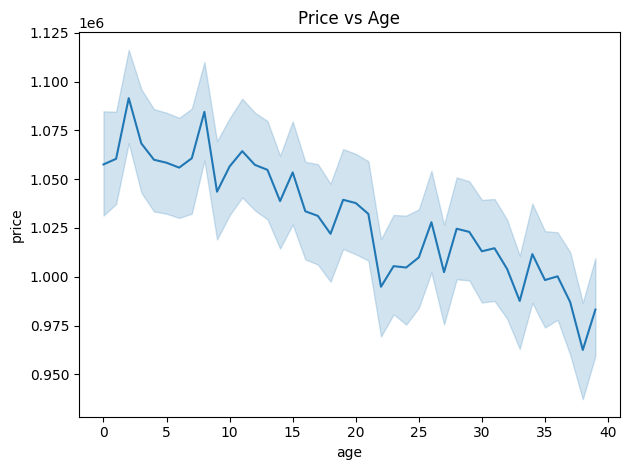

In [26]:
sns.lineplot(x = 'age', y = 'price', data = df)
plt.title("Price vs Age")
plt.tight_layout()
plt.show()

-  **For distribution categorial**

In [27]:
df.columns

Index(['area', 'bedrooms', 'bathrooms', 'floors', 'age', 'distance', 'garage',
       'parking', 'garden', 'security', 'school_nearby', 'hospital_nearby',
       'shopping_mall_nearby', 'public_transport', 'crime_rate',
       'population_density', 'location', 'income_level', 'price'],
      dtype='object')

In [29]:
df.location.value_counts()

,count
location,
medium,16756
low,16642
premium,16602


In [30]:
df.income_level.value_counts()

,count
income_level,
mid,16738
low,16651
high,16611


/tmp/ipykernel_8563/260815693.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x  ='location',  data = df, palette = 'Set1')


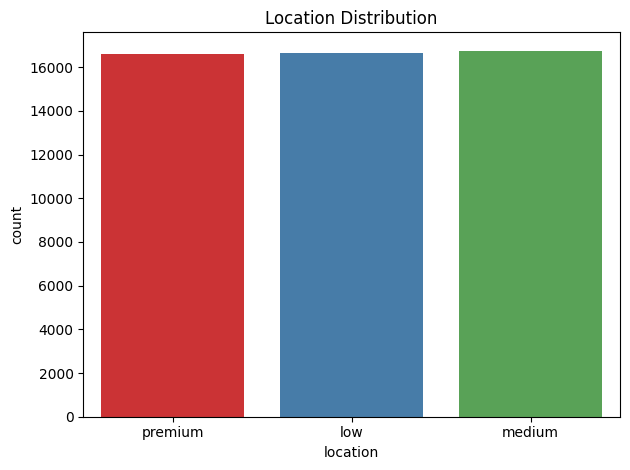

In [31]:
sns.countplot(x  ='location',  data = df, palette = 'Set1')
plt.title("Location Distribution")
plt.tight_layout()
plt.show()

<Axes: ylabel='count'>

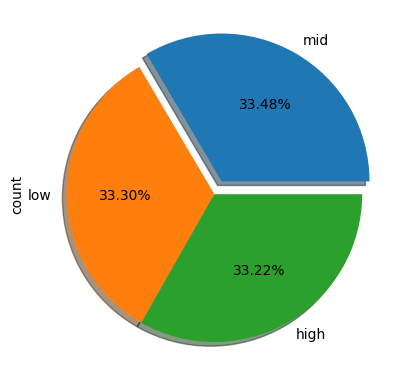

In [32]:
df.income_level.value_counts().plot(kind = "pie", autopct = "%.2f%%", explode =(0.1, 0, 0), shadow = True)

##  **Step - 4: Feature Engineering**

In [33]:
df_encoded = df.copy()

In [34]:
df_encoded.head()

,area,bedrooms,bathrooms,floors,age,distance,garage,parking,garden,security,school_nearby,hospital_nearby,shopping_mall_nearby,public_transport,crime_rate,population_density,location,income_level,price
0,1360,6,2,2,9,10,0,0,1,0,1,0,1,0,6.939333,7242,premium,low,595249
1,4272,5,2,3,24,8,1,0,0,1,1,1,1,0,0.400918,7729,low,low,1571208
2,3592,1,4,3,4,20,0,1,1,1,0,1,0,1,6.292386,1081,premium,mid,1379942
3,966,5,2,2,6,14,1,0,0,0,0,1,1,0,8.964112,8912,medium,low,436781
4,4926,4,3,1,18,9,0,0,0,0,1,0,1,1,2.843309,8146,low,mid,1792424


In [35]:
# total_rooms
df_encoded['total_rooms']= df_encoded['bedrooms'] + df_encoded['bathrooms']

In [36]:
# Area per rooms
df_encoded['area_per_rooms'] = df_encoded['area'] / df_encoded['total_rooms']

In [38]:
# is multifloors
df_encoded['is_multifloor'] = (df_encoded['floors'] > 1).astype(int)

In [39]:
df_encoded.head()

,area,bedrooms,bathrooms,floors,age,distance,garage,parking,garden,security,...,shopping_mall_nearby,public_transport,crime_rate,population_density,location,income_level,price,total_rooms,area_per_rooms,is_multifloor
0,1360,6,2,2,9,10,0,0,1,0,...,1,0,6.939333,7242,premium,low,595249,8,170.000000,1
1,4272,5,2,3,24,8,1,0,0,1,...,1,0,0.400918,7729,low,low,1571208,7,610.285714,1
2,3592,1,4,3,4,20,0,1,1,1,...,0,1,6.292386,1081,premium,mid,1379942,5,718.400000,1
3,966,5,2,2,6,14,1,0,0,0,...,1,0,8.964112,8912,medium,low,436781,7,138.000000,1
4,4926,4,3,1,18,9,0,0,0,0,...,1,1,2.843309,8146,low,mid,1792424,7,703.714286,0


In [40]:
df_encoded.dtypes

,0
area,int64
bedrooms,int64
bathrooms,int64
floors,int64
age,int64
distance,int64
garage,int64
parking,int64
garden,int64
security,int64


In [41]:
df_encoded.describe()

,area,bedrooms,bathrooms,floors,age,distance,garage,parking,garden,security,school_nearby,hospital_nearby,shopping_mall_nearby,public_transport,crime_rate,population_density,price,total_rooms,area_per_rooms,is_multifloor
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,5.000000e+04,50000.000000,50000.000000,50000.000000
mean,2752.970540,3.496040,2.498040,1.997060,19.573740,14.968700,0.500540,0.497300,0.500280,0.496220,0.501100,0.498320,0.498320,0.500040,5.006444,5065.94598,1.030260e+06,5.994080,533.825004,0.666120
std,1297.148134,1.712146,1.117704,0.815368,11.552502,8.363714,0.500005,0.499998,0.500005,0.499991,0.500004,0.500002,0.500002,0.500005,2.876776,2864.34322,4.580199e+05,2.044409,370.721046,0.471602
min,500.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000311,100.00000,9.090000e+04,2.000000,50.200000,0.000000
25%,1630.000000,2.000000,1.000000,1.000000,10.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.523018,2575.00000,6.357365e+05,4.000000,272.142857,0.000000
50%,2756.000000,3.000000,2.000000,2.000000,20.000000,15.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,5.022946,5060.50000,1.031762e+06,6.000000,458.683333,1.000000
75%,3872.000000,5.000000,3.000000,3.000000,30.000000,22.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.479632,7543.00000,1.423101e+06,8.000000,685.839286,1.000000
max,4999.000000,6.000000,4.000000,3.000000,39.000000,29.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,9.999869,9999.00000,1.996474e+06,10.000000,2498.500000,1.000000


## **Step - 5: For label Categorical Features**


- **OneHotEncoding is the best way to convert object data into integer values.**

In [42]:
from sklearn.preprocessing import LabelEncoder

In [43]:
if 'location' in df_encoded.columns:
  le = LabelEncoder()
  df_encoded['location_enc'] = le.fit_transform(df_encoded['location'])

In [44]:
df_encoded.income_level.value_counts()

,count
income_level,
mid,16738
low,16651
high,16611


In [45]:
# encode 'income_level' using ordinal encoding
income_level_mapping = {'low': 0, 'mid': 1, 'high': 2}
df_encoded['income_level_enc'] = df_encoded['income_level'].map(income_level_mapping)

In [46]:
df_encoded.drop(['location', 'income_level'], axis = 1, inplace = True)

In [47]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   area                  50000 non-null  int64  
 1   bedrooms              50000 non-null  int64  
 2   bathrooms             50000 non-null  int64  
 3   floors                50000 non-null  int64  
 4   age                   50000 non-null  int64  
 5   distance              50000 non-null  int64  
 6   garage                50000 non-null  int64  
 7   parking               50000 non-null  int64  
 8   garden                50000 non-null  int64  
 9   security              50000 non-null  int64  
 10  school_nearby         50000 non-null  int64  
 11  hospital_nearby       50000 non-null  int64  
 12  shopping_mall_nearby  50000 non-null  int64  
 13  public_transport      50000 non-null  int64  
 14  crime_rate            50000 non-null  float64
 15  population_density 

In [48]:
df_encoded['area_per_rooms'] = df_encoded['area_per_rooms'].astype(int)

In [49]:
df_encoded.head()

,area,bedrooms,bathrooms,floors,age,distance,garage,parking,garden,security,...,shopping_mall_nearby,public_transport,crime_rate,population_density,price,total_rooms,area_per_rooms,is_multifloor,location_enc,income_level_enc
0,1360,6,2,2,9,10,0,0,1,0,...,1,0,6.939333,7242,595249,8,170,1,2,0
1,4272,5,2,3,24,8,1,0,0,1,...,1,0,0.400918,7729,1571208,7,610,1,0,0
2,3592,1,4,3,4,20,0,1,1,1,...,0,1,6.292386,1081,1379942,5,718,1,2,1
3,966,5,2,2,6,14,1,0,0,0,...,1,0,8.964112,8912,436781,7,138,1,1,0
4,4926,4,3,1,18,9,0,0,0,0,...,1,1,2.843309,8146,1792424,7,703,0,0,1


In [50]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   area                  50000 non-null  int64  
 1   bedrooms              50000 non-null  int64  
 2   bathrooms             50000 non-null  int64  
 3   floors                50000 non-null  int64  
 4   age                   50000 non-null  int64  
 5   distance              50000 non-null  int64  
 6   garage                50000 non-null  int64  
 7   parking               50000 non-null  int64  
 8   garden                50000 non-null  int64  
 9   security              50000 non-null  int64  
 10  school_nearby         50000 non-null  int64  
 11  hospital_nearby       50000 non-null  int64  
 12  shopping_mall_nearby  50000 non-null  int64  
 13  public_transport      50000 non-null  int64  
 14  crime_rate            50000 non-null  float64
 15  population_density 

In [51]:
df_backup = df_encoded.copy()

In [52]:
print(df.corr(numeric_only = True)['price'].sort_values(ascending =False))

price                   1.000000
area                    0.991364
bedrooms                0.047123
bathrooms               0.025626
parking                 0.015492
hospital_nearby         0.013600
population_density      0.010539
garden                  0.008736
garage                  0.004506
floors                  0.003135
security                0.001659
school_nearby          -0.000416
public_transport       -0.001022
shopping_mall_nearby   -0.003412
crime_rate             -0.016964
distance               -0.028118
age                    -0.058757
Name: price, dtype: float64


## **Step - 6: Train - Test Split**

In [53]:
import numpy as np

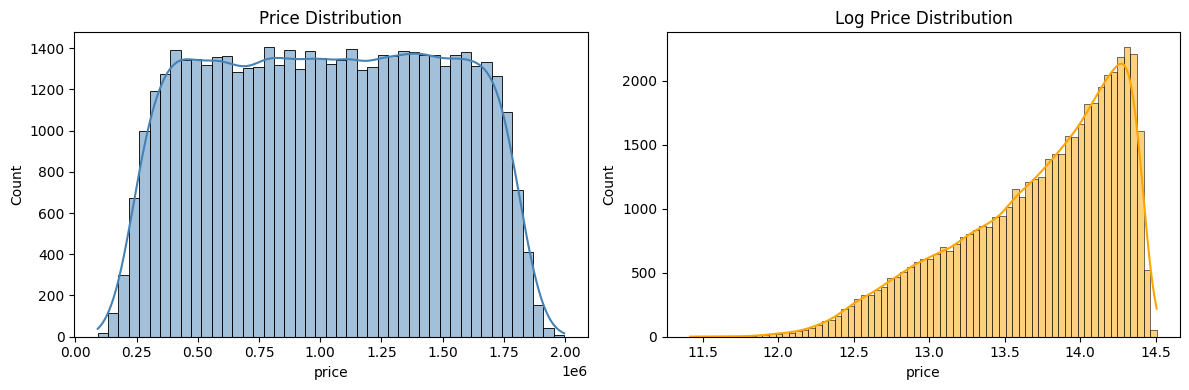

In [54]:
fig, axes = plt.subplots(1, 2, figsize = (12, 4))

# Before log
axes[0].set_title("Price Distribution")
sns.histplot(df_encoded['price'], kde = True, ax = axes[0], color = 'steelblue')

# After log
axes[1].set_title("Log Price Distribution")
sns.histplot(df_encoded['price'].apply(np.log1p), kde = True, ax = axes[1], color = 'orange')

plt.tight_layout()
plt.show()

In [55]:
print("Skewness (original):", df_encoded['price'].skew())
print("Skewness (log)     :", np.log1p(df_encoded['price']).skew())

Skewness (original): -0.007444317112388141
Skewness (log)     : -0.7885332014746177


## **Step - 7: Model Building**

In [56]:
from sklearn.model_selection import train_test_split

In [57]:
# use original price no log
X = df_encoded.drop('price', axis = 1)
y = df_encoded['price']

In [58]:
X_train, X_test,y_train, y_test =train_test_split(X, y, test_size = 0.2, random_state = 42)

In [59]:
print("X_train", X_train.shape)
print("X_test", X_test.shape)
print("y_train", y_train.shape)
print("y_test", y_test.shape)

X_train (40000, 21)
X_test (10000, 21)
y_train (40000,)
y_test (10000,)


 - **Apply LinearRegression model**

In [60]:
from sklearn.linear_model import LinearRegression

In [61]:
# Liner Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [62]:
# Predict the test data
lr_predict = lr.predict(X_test)
lr_predict

array([ 732314.61624989,  426266.25612073, 1698119.91589261, ...,
       1063968.69282759, 1172132.45177014, 1735163.71128423])

In [63]:
len(lr_predict)

10000

## **Step - 8: Model Evaluation**

In [64]:
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error

In [65]:
# 1. R2_score
print("Linear Regression R2_score:", r2_score(y_test, lr_predict))


Linear Regression R2_score: 0.9980833638593808


In [66]:
# 2.MAE (Mean absolute error)
mae = mean_absolute_error(y_test, lr_predict)
print("Linear Regression MAE:", mae)

Linear Regression MAE: 16095.40555518649


In [67]:
# 3. MSE (Mean squared error)
mse = mean_squared_error(y_test, lr_predict)
print("Linear Regression MSE:", mse)

Linear Regression MSE: 403728425.49591994


In [68]:
# 4. Root mean square error
rmse = np.sqrt(mse)
print("Linear Regression RMSE:", rmse)

Linear Regression RMSE: 20092.99443825932


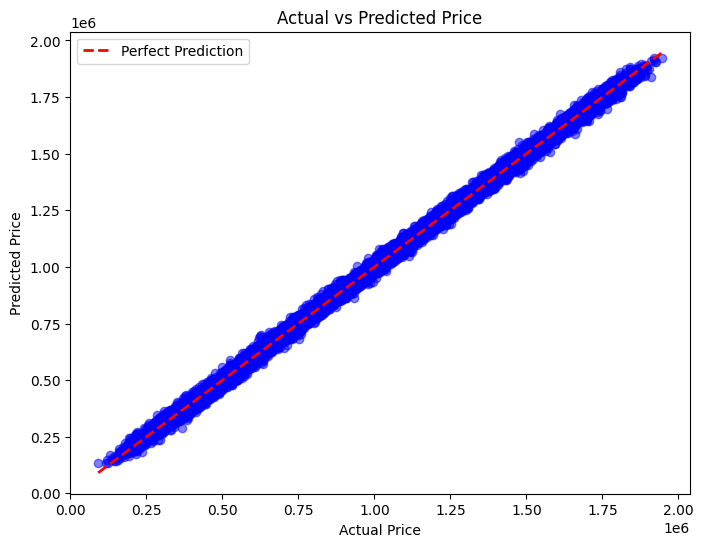

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, lr_predict, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.legend()
plt.savefig('actual_vs_predicted.png')
plt.show()

 - **Apply GradientBoost and RandomForest**

In [70]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

In [71]:
from sklearn.linear_model import Ridge, Lasso

In [73]:
models =  {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha= 1.0),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators = 100, random_state = 42),
    'Random Forest': RandomForestRegressor(n_estimators = 100, random_state = 42)
}

In [85]:
results = []

for name, model in models.items():
  model.fit(X_train, y_train)
  pred = model.predict(X_test)
  r2  = r2_score(y_test, pred)
  mae  = mean_absolute_error(y_test, pred)
  mse = mean_squared_error(y_test, pred)
  rmse = np.sqrt(mse)
  results.append({'Model':name, 'R²':r2, 'MAE': mae, 'MSE':mse, 'RMSE':rmse})

In [86]:
print(f"{name:<22} R²={r2:.4f} mae={mae:,.0f} mse={mse:,.0f} rmse= {rmse:,.0f}")

Random Forest          R²=0.9967 mae=20,967 mse=691,910,038 rmse= 26,304


## **Step - 9: Model Comparison Chart**

In [87]:
import pandas as pd
results_df = pd.DataFrame(results).sort_values('R²',ascending=False)

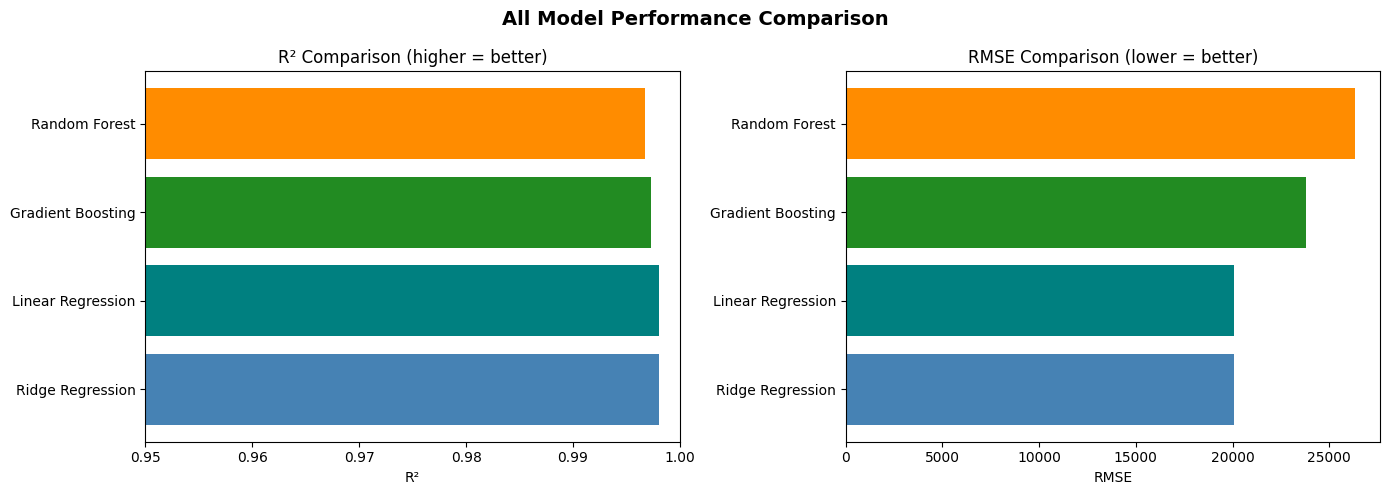

In [92]:
fig, axes = plt.subplots(1, 2, figsize= (14, 5))
colors = ['steelblue', 'teal', 'forestgreen', 'darkorange','crimson']

axes[0].barh(results_df['Model'], results_df['R²'], color=colors)
axes[0].set_xlabel('R²')
axes[0].set_title('R² Comparison (higher = better)')
axes[0].set_xlim(0.95, 1.0)

axes[1].barh(results_df['Model'], results_df['RMSE'], color=colors)
axes[1].set_xlabel('RMSE')
axes[1].set_title('RMSE Comparison (lower = better)')

plt.suptitle('All Model Performance Comparison', fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.show()

## **Step - 10: Cross Validation**

In [97]:
from sklearn.model_selection import cross_val_score

In [98]:
best_model = RandomForestRegressor(n_estimators = 100, random_state = 42)

In [99]:
cv_scores = cross_val_score(best_model, X, y, cv= 5, scoring = 'r2')

In [100]:
print("\nCross Validation R² Scores:", cv_scores)
print("Mean CV R² Score:", cv_scores.mean().round(4))
print("Std CV R² Score:", cv_scores.std().round(4))


Cross Validation R² Scores: [0.99663263 0.99664838 0.99669975 0.99669195 0.9966801 ]
Mean CV R² Score: 0.9967
Std CV R² Score: 0.0


## **Step - 11: Save Best Model**

In [101]:
import joblib

In [103]:
best_model.fit(X_train, y_train)
joblib.dump(best_model, 'house_price_model.pkl')
print("\nModel saved as house_price_model.pkl")


Model saved as house_price_model.pkl
